# PowerPulse: Household Energy Usage Forecast

This notebook builds an end-to-end machine learning pipeline to analyze and forecast household electricity consumption using historical data from the UCI Machine Learning Repository.


##  Import Required Libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/Othercomputers/My laptop/MY Work Space/PowerPulse')
!ls

data					    requirements.txt
PowerPulse_Household_Energy_Forecast.ipynb  Untitled-1.ipynb


In [3]:
!pip install -r requirements.txt

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm


##  Load Dataset

In [5]:
df = pd.read_csv(
    "data/household_power_consumption.txt",
    sep=";",
    na_values="?",
    low_memory=False
)

df.head()


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


##  Exploratory Data Analysis (EDA)

Review Data Structure and Summary

In [6]:
# EDA Following PowerPulse Project Guidelines

# 1. Review Data Structure and Summary
print(df.info())
print(df.describe())

# 2. Verify Missing Data
print("Missing values per column:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB
None
       Global_active_power  Global_reactive_power       Voltage  \
count         2.049280e+06           2.049280e+06  2.049280e+06   
mean          1.091615e+00           1.237145e-01  2.408399e+02   
std           1.057294e+00           1.127220e-01  3.239987e+00   
min           7.600000e-02           0.000000e+00  2.232000e+02   
25%           3.080000e-01           4.800000e-02  2.389900e+02   
50%           6.020000e-01     

## **Additional Information**

This archive contains 2075259 measurements gathered in a house located in Sceaux (7km of Paris, France) between December 2006 and November 2010 (47 months).
Notes:

1.voltage=(global_active_power*1000/60 - sub_metering_1 - sub_metering_2 - sub_metering_3) represents the active energy consumed every minute (in watt hour) in the household by electrical equipment not measured in sub-meterings 1, 2 and 3.

2.The dataset contains some missing values in the measurements (nearly 1,25% of the rows). All calendar timestamps are present in the dataset but for some timestamps, the measurement values are missing: a missing value is represented by the absence of value between two consecutive semi-colon attribute separators. For instance, the dataset shows missing values on April 28, 2007.

## **Variable Type Analysis**

Variable Name	Role	Type	Description	Units	Missing Values
Date	Feature	Date			no
Time	Feature	Categorical			no
Global_active_power	Feature	Continuous			no
Global_reactive_power	Feature	Continuous			no
Voltage	Feature	Continuous			no
Global_intensity	Feature	Continuous			no
Sub_metering_1	Feature	Continuous			no
Sub_metering_2	Feature	Continuous			no
Sub_metering_3	Feature	Continuous			no

**Exploratory Visualizations**

## Distribution

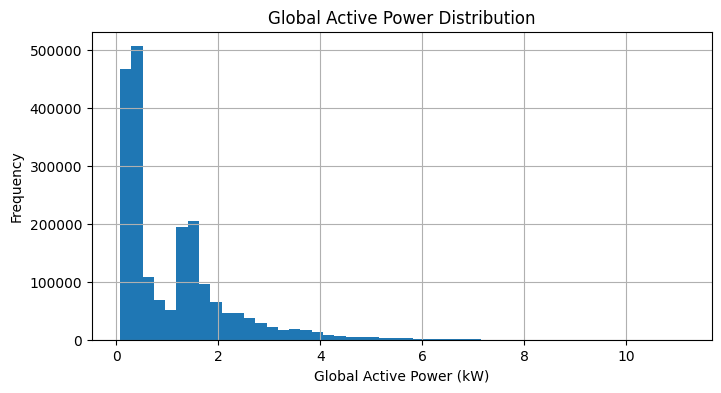

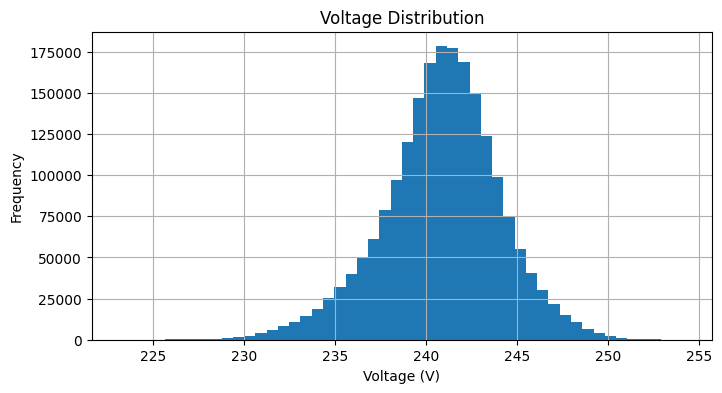

In [7]:
# Global Active Power Distribution
plt.figure(figsize=(8,4))
df['Global_active_power'].hist(bins=50)
plt.title('Global Active Power Distribution')
plt.xlabel('Global Active Power (kW)')
plt.ylabel('Frequency')
plt.show()

# Voltage Distribution
plt.figure(figsize=(8,4))
df['Voltage'].hist(bins=50)
plt.title('Voltage Distribution')
plt.xlabel('Voltage (V)')
plt.ylabel('Frequency')
plt.show()

## Correlation Heatmap

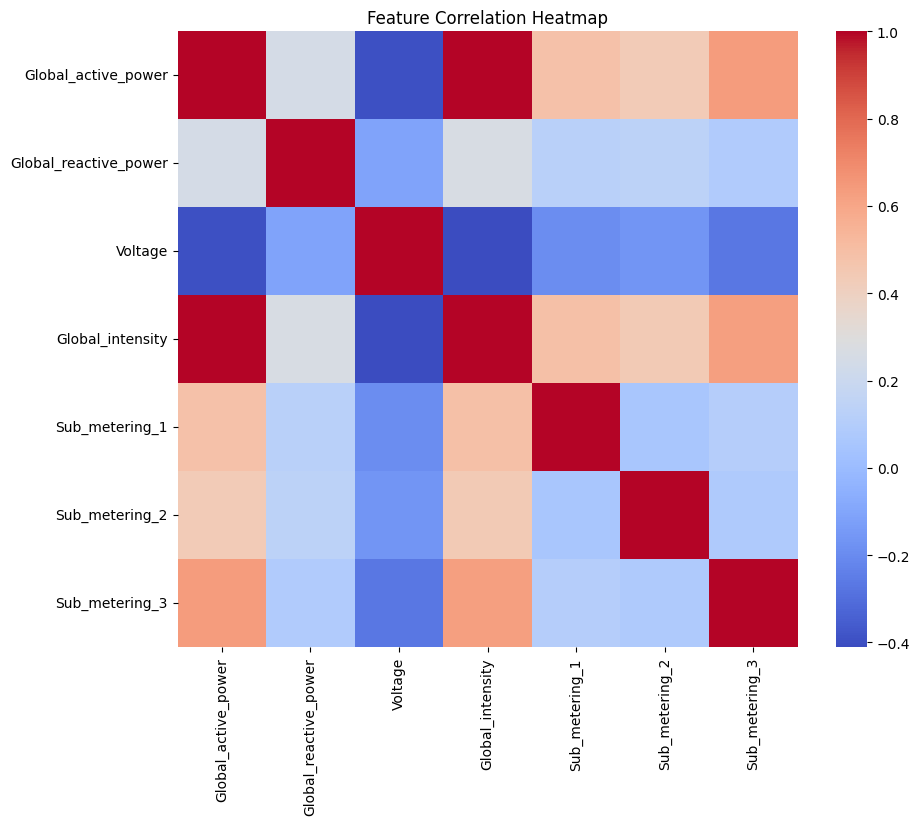

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## Sub-Metering Comparison

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


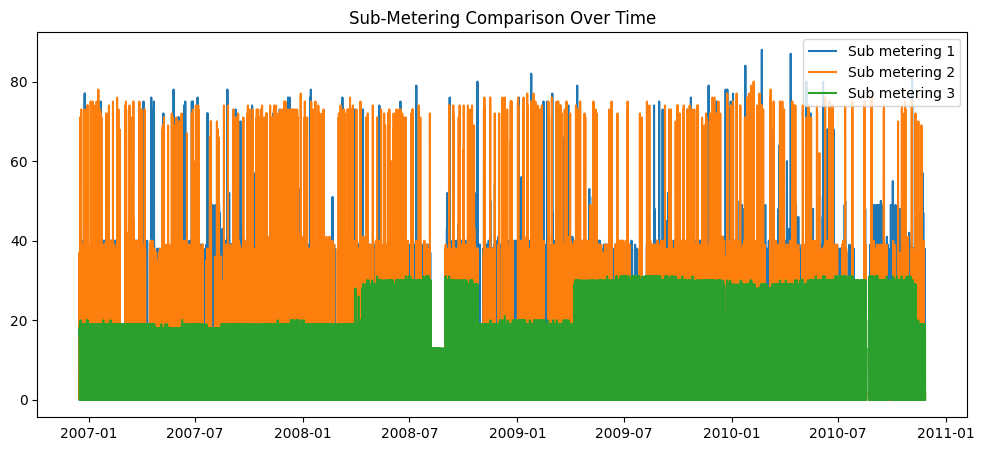

In [20]:
plt.figure(figsize=(12,5))
plt.plot(df['Sub_metering_1'], label='Sub metering 1')
plt.plot(df['Sub_metering_2'], label='Sub metering 2')
plt.plot(df['Sub_metering_3'], label='Sub metering 3')
plt.title('Sub-Metering Comparison Over Time')
plt.legend()
plt.show()

 ## Time Series Decomposition

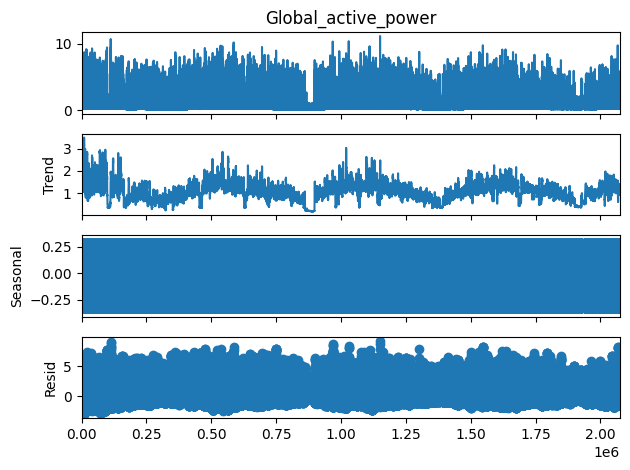

EDA completed as per PowerPulse project approach.


In [29]:
decomp = sm.tsa.seasonal_decompose(
    df['Global_active_power'].dropna(),
    model='additive',
    period=1440  # daily seasonality for minute-level data
)
decomp.plot()
plt.show()

print("EDA completed as per PowerPulse project approach.")

##  Data Preprocessing

## Ensure DateTime Index

In [30]:
if not isinstance(df.index, pd.DatetimeIndex):
    df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
    df = df.drop(columns=['Date', 'Time'])
    df = df.set_index('DateTime')

df = df.sort_index()

## Handle Missing Values

In [38]:
df = df.fillna(method='ffill')

/tmp/ipython-input-569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [40]:
print("Missing values after preprocessing:")
print(df.isnull().sum())

,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


## Resampling (Minute → Hourly)

In [42]:
# Reduces noise and improves model stability
df_hourly = df.resample('H').mean()

print("Shape after hourly resampling:", df_hourly.shape)

Shape after hourly resampling: (34589, 7)


/tmp/ipython-input-453760440.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


##  Feature Engineering

In [43]:
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day'] = df_hourly.index.day
df_hourly['month'] = df_hourly.index.month
df_hourly['dayofweek'] = df_hourly.index.dayofweek
df_hourly['rolling_mean_24h'] = (
    df_hourly['Global_active_power']
    .rolling(window=24)
    .mean()
)
df_hourly = df_hourly.dropna()
print(df_hourly.info())
df_hourly.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34566 entries, 2006-12-17 16:00:00 to 2010-11-26 21:00:00
Freq: h
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    34566 non-null  float64
 1   Global_reactive_power  34566 non-null  float64
 2   Voltage                34566 non-null  float64
 3   Global_intensity       34566 non-null  float64
 4   Sub_metering_1         34566 non-null  float64
 5   Sub_metering_2         34566 non-null  float64
 6   Sub_metering_3         34566 non-null  float64
 7   hour                   34566 non-null  int32  
 8   day                    34566 non-null  int32  
 9   month                  34566 non-null  int32  
 10  dayofweek              34566 non-null  int32  
 11  rolling_mean_24h       34566 non-null  float64
dtypes: float64(8), int32(4)
memory usage: 2.9 MB
None


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day,month,dayofweek,rolling_mean_24h
DateTime,,,,,,,,,,,,
2006-12-17 16:00:00,3.326033,0.093133,236.781833,14.006667,8.583333,0.066667,17.166667,16,17,12,6,2.499145
2006-12-17 17:00:00,3.406767,0.166633,234.229833,14.510000,0.000000,0.466667,16.816667,17,17,12,6,2.465140
2006-12-17 18:00:00,3.697100,0.135067,234.372333,15.750000,0.000000,0.000000,16.833333,18,17,12,6,2.467844
2006-12-17 19:00:00,2.908400,0.265167,233.195667,12.516667,0.000000,0.516667,16.683333,19,17,12,6,2.447351
2006-12-17 20:00:00,3.361500,0.271500,236.426500,14.276667,0.000000,1.116667,17.116667,20,17,12,6,2.451224


## external data Merge with your energy data

In [44]:
weather = pd.read_csv("export.csv")

weather['date'] = pd.to_datetime(weather['date']).dt.date

weather = weather[['date', 'tavg']]  # keep it simple

weather.rename(columns={'tavg': 'avg_temperature'}, inplace=True)

weather.head()


,date,avg_temperature
0,2006-12-01,8.1
1,2006-12-02,10.2
2,2006-12-03,9.6
3,2006-12-04,12.0
4,2006-12-05,13.5


In [47]:
weather['avg_temperature'].isnull().sum()

np.int64(82)

In [56]:
final_df['avg_temperature'] = final_df['avg_temperature'].fillna(method='ffill')

/tmp/ipython-input-3240428014.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  final_df['avg_temperature'] = final_df['avg_temperature'].fillna(method='ffill')


In [ ]:
df_hourly['date'] = df_hourly.index.date

final_df = pd.merge(
    df_hourly,
    weather,
    on='date',
    how='left'
)
final_df.to_csv("final_df.csv")
final_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day,month,dayofweek,rolling_mean_24h,date,avg_temperature
0,3.326033,0.093133,236.781833,14.006667,8.583333,0.066667,17.166667,16,17,12,6,2.499145,2006-12-17,4.4
1,3.406767,0.166633,234.229833,14.510000,0.000000,0.466667,16.816667,17,17,12,6,2.465140,2006-12-17,4.4
2,3.697100,0.135067,234.372333,15.750000,0.000000,0.000000,16.833333,18,17,12,6,2.467844,2006-12-17,4.4
3,2.908400,0.265167,233.195667,12.516667,0.000000,0.516667,16.683333,19,17,12,6,2.447351,2006-12-17,4.4
4,3.361500,0.271500,236.426500,14.276667,0.000000,1.116667,17.116667,20,17,12,6,2.451224,2006-12-17,4.4


##  Train-Test Split

In [58]:
train = final_df.loc[:'2009-12-31']
test  = final_df.loc['2010-01-01':]

## Model Training

In [62]:
# -----------------------------
# GRADIENT BOOSTING REGRESSION
# -----------------------------

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 1. Define target and features
target = 'Global_active_power'

feature_cols = [
    'hour',
    'dayofweek',
    'month',
    'rolling_mean_24h'
]

# (Optional) include weather if present
if 'avg_temperature' in final_df.columns:
    feature_cols.append('avg_temperature')

X_train = train[feature_cols]
y_train = train[target]

X_test  = test[feature_cols]
y_test  = test[target]

required_cols = feature_cols + [target]

train_clean = train[required_cols].dropna()
test_clean  = test[required_cols].dropna()

X_train = train_clean[feature_cols]
y_train = train_clean[target]

X_test  = test_clean[feature_cols]
y_test  = test_clean[target]


# 2. Initialize Gradient Boosting model
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# 3. Train the model
gbr.fit(X_train, y_train)

# 4. Predict on test data
y_pred = gbr.predict(X_test)

# 5. Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print("Gradient Boosting RMSE:", rmse)
print("Gradient Boosting MAE :", mae)


Gradient Boosting RMSE: 0.5680049724707283
Gradient Boosting MAE : 0.4141411990698831


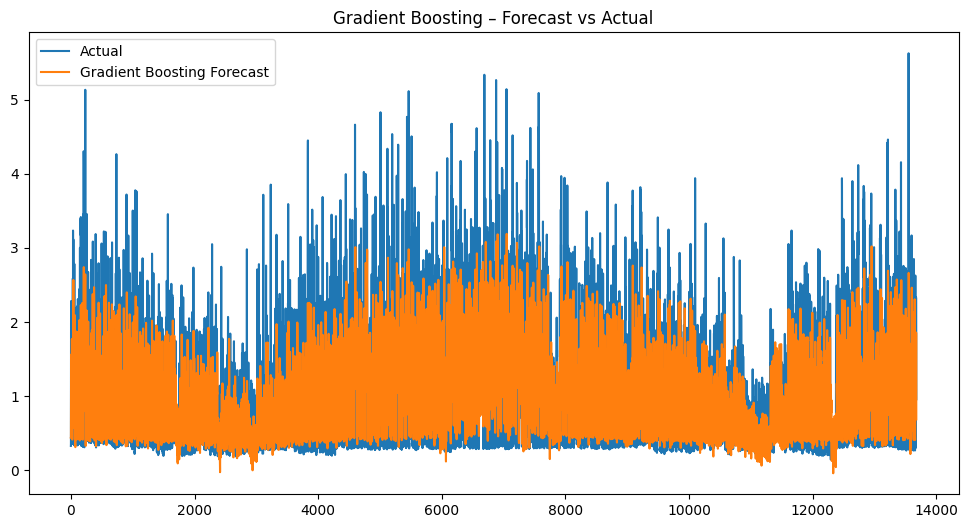

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Gradient Boosting Forecast')
plt.title('Gradient Boosting – Forecast vs Actual')
plt.legend()
plt.show()


## Model Evaluation

In [65]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print("Gradient Boosting RMSE:", rmse)
print("Gradient Boosting MAE :", mae)


Gradient Boosting RMSE: 0.5680049724707283
Gradient Boosting MAE : 0.4141411990698831


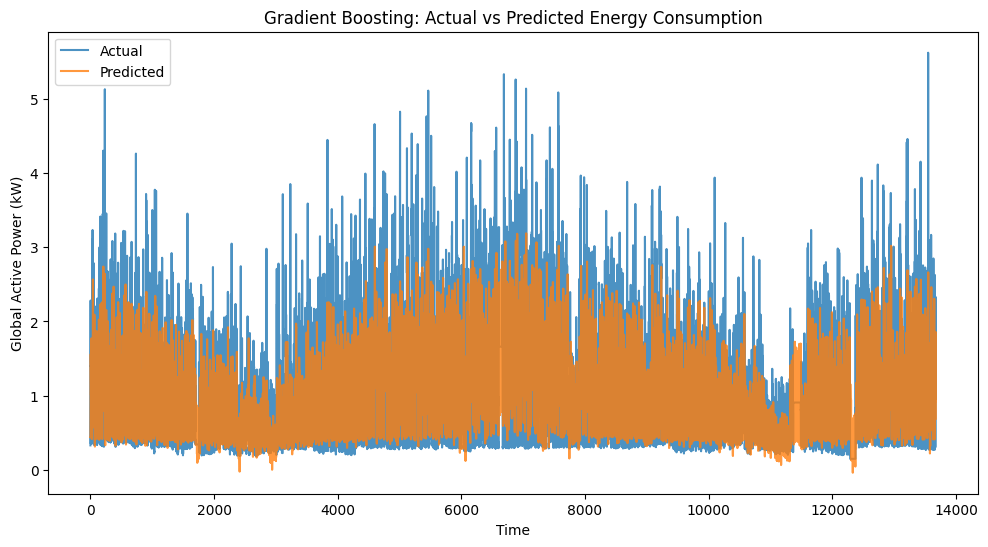

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual', alpha=0.8)
plt.plot(y_pred, label='Predicted', alpha=0.8)
plt.title('Gradient Boosting: Actual vs Predicted Energy Consumption')
plt.xlabel('Time')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.show()


## Feature Importance

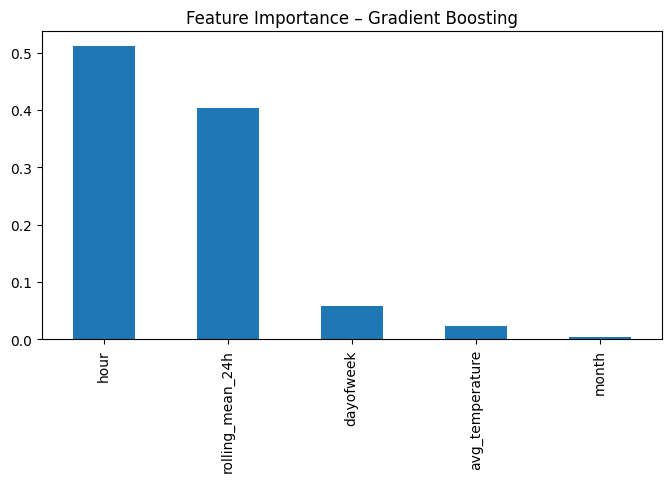

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    gbr.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

importance.plot(kind='bar', figsize=(8,4))
plt.title('Feature Importance – Gradient Boosting')
plt.show()


## Conclusion
- Tree-based models outperform linear regression
- Time-based features strongly influence energy usage
- Useful for demand forecasting and energy optimization

In [70]:
import joblib

joblib.dump(gbr, "gradient_boosting_energy_model.pkl")

joblib.dump(feature_cols, "feature_cols.pkl")



['feature_cols.pkl']